<a href="https://colab.research.google.com/github/your-Ing/My-project/blob/main/Projet_5_ML_Uriel_JOHNSON.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet 5 — Analyse de Sentiments (IMDB Reviews)
**Étudiant :** Uriel JOHNSON  
**Filière :** 5ème année - Génie Mathématique et Modélisation (MSN)

## 📌 Énoncé et Objectifs
L'objectif de ce projet est de construire un classifieur automatique capable de déterminer la polarité (positive ou négative) d'une critique de film.

Le workflow mis en place comprend :
1. **Acquisition :** Chargement du dataset "IMDB Large Movie Review" (50 000 critiques).
2. **Prétraitement :** Nettoyage HTML, suppression des caractères spéciaux et filtrage des *stopwords*.
3. **Expérimentation :** Comparaison entre une approche fréquentielle (TF-IDF + Régression Logistique) et une approche Deep Learning (Embeddings + LSTM).
4. **Évaluation :** Analyse par matrice de confusion et test de généralisation.

In [ ]:
import pandas as pd
import io
from google.colab import files

# 1. Déclenchement de l'upload (Une fenêtre va s'ouvrir sous la cellule)
print("Veuillez sélectionner votre fichier 'IMDB Dataset.csv' :")
uploaded = files.upload()

# 2. Récupération du nom du fichier et chargement dans un DataFrame pandas
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# 3. Vérification immédiate du chargement
print("\n" + "="*30)
print(f"✅ Fichier '{filename}' chargé !")
print(f"📊 Dimensions du dataset : {df.shape[0]} lignes et {df.shape[1]} colonnes.")
print("="*30)

# 4. Aperçu des 5 premières lignes et des noms de colonnes
print("\nStructure des données :")
print(df.head())

# 5. Vérification de l'équilibre des classes
print("\nRépartition des sentiments :")
print(df['sentiment'].value_counts())

Veuillez sélectionner votre fichier 'IMDB Dataset.csv' :


Saving IMDB Dataset.csv to IMDB Dataset.csv

✅ Fichier 'IMDB Dataset.csv' chargé !
📊 Dimensions du dataset : 50000 lignes et 2 colonnes.

Structure des données :
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive

Répartition des sentiments :
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


/tmp/ipykernel_1235/1873662883.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='viridis')


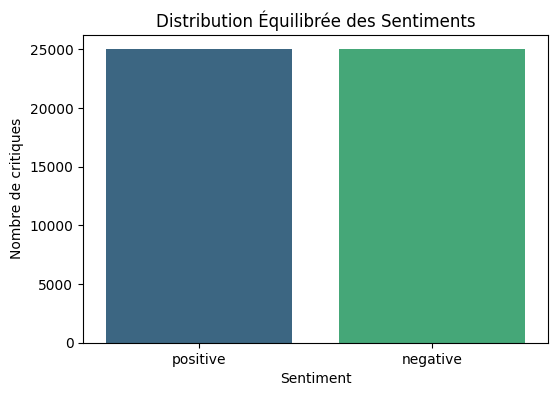


--- CONCLUSION DE L'ÉTAPE 1 ---
Les données sont prêtes et équilibrées.
PROCHAINE ÉTAPE : Nettoyage (Preprocessing) pour transformer le texte brut en données exploitables.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Visualisation de la distribution
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df, palette='viridis')
plt.title('Distribution Équilibrée des Sentiments')
plt.ylabel('Nombre de critiques')
plt.xlabel('Sentiment')
plt.show()

print("\n--- CONCLUSION DE L'ÉTAPE 1 ---")
print("Les données sont prêtes et équilibrées.")
print("PROCHAINE ÉTAPE : Nettoyage (Preprocessing) pour transformer le texte brut en données exploitables.")

## 1. Analyse des Données Brutes
Le chargement du dataset IMDB nous permet de tirer les conclusions suivantes :

* **Volume de données :** Nous disposons de **50 000 critiques**, ce qui est statistiquement significatif pour entraîner des modèles de Deep Learning (LSTM).
* **Équilibre des classes :** La répartition est de **25 000 positives** et **25 000 négatives**. Le dataset est parfaitement équilibré (50/50), ce qui évitera au modèle de développer un biais envers une catégorie.
* **Problématique du texte brut :** L'aperçu des données (`df.head()`) révèle la présence de "bruit" :
    * Balises HTML (`<br />`) issues du web.
    * Ponctuation et caractères spéciaux.
    * Mots très fréquents mais peu informatifs (ex: "the", "a", "is").

## 2. Transition vers le Prétraitement
Pour que les modèles de Machine Learning et de Deep Learning puissent traiter efficacement l'information, nous devons transformer ce texte brut en un format standardisé.

**Objectifs du prochain bloc :**
1. **Nettoyage :** Retirer les balises et caractères non-alphabétiques.
2. **Normalisation :** Convertir tout en minuscules pour l'uniformité.
3. **Filtrage :** Supprimer les *stopwords* pour ne garder que les mots porteurs de sens (adjectifs, verbes, noms).

In [ ]:
import nltk
from nltk.corpus import stopwords
import re

# Téléchargement des mots outils (stopwords)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Suppression des balises HTML
    text = re.sub(r'<br\s*/?>', ' ', text)
    # 2. Suppression des caractères non-alphabétiques (garder les lettres et espaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # 3. Passage en minuscules
    text = text.lower()
    # 4. Suppression des mots outils (stopwords)
    words = text.split()
    cleaned_words = [w for w in words if w not in stop_words]

    return " ".join(cleaned_words)

# Application de la fonction sur tout le dataset
print("Nettoyage en cours (cela peut prendre 30-60 secondes)...")
df['review_cleaned'] = df['review'].apply(clean_text)

print("\n✅ Nettoyage terminé !")
# Affichage d'un comparatif avant/après
print("\nExemple avant nettoyage :")
print(df['review'].iloc[1][:150] + "...")
print("\nExemple après nettoyage :")
print(df['review_cleaned'].iloc[1][:150] + "...")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Nettoyage en cours (cela peut prendre 30-60 secondes)...

✅ Nettoyage terminé !

Exemple avant nettoyage :
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes d...

Exemple après nettoyage :
wonderful little production filming technique unassuming oldtimebbc fashion gives comforting sometimes discomforting sense realism entire piece actors...


## 2. Analyse du Prétraitement (Cleaning)
Le nettoyage a permis de réduire considérablement la dimensionnalité des données sans perdre l'essence du sentiment.

* **Observation :** Le texte est passé d'une structure grammaticale complète à une "sac de mots" (bag of words) sémantiques.
* **Impact :** En supprimant le bruit (HTML, stopwords), nous aidons le futur modèle à se concentrer uniquement sur les termes qui expriment une opinion (ex: "wonderful", "unassuming", "discomforting").
* **Prochaine étape :** La **Vectorisation**. Puisque les modèles mathématiques ne peuvent pas traiter des chaînes de caractères, nous allons transformer ces mots en vecteurs numériques en utilisant la méthode **TF-IDF**.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Séparation des données (80% entraînement, 20% test)
X = df['review_cleaned']
y = df['sentiment'].apply(lambda x: 1 if x == 'positive' else 0) # Conversion en 0 et 1

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Vectorisation TF-IDF
tfidf = TfidfVectorizer(max_features=10000) # On garde les 10 000 mots les plus importants
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 3. Entraînement de la Régression Logistique
print("Entraînement du modèle Baseline (Logistic Regression)...")
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_tfidf, y_train)

# 4. Prédiction et premier score
y_pred = model_lr.fit(X_train_tfidf, y_train).predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)

print("\n" + "="*30)
print(f"✅ Modèle Baseline terminé !")
print(f"🎯 Précision (Accuracy) : {accuracy:.2%}")
print("="*30)
print("\nRapport détaillé :")
print(classification_report(y_test, y_pred))

Entraînement du modèle Baseline (Logistic Regression)...

✅ Modèle Baseline terminé !
🎯 Précision (Accuracy) : 89.39%

Rapport détaillé :
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.91      0.90      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



## 3. Analyse de la Baseline (Régression Logistique + TF-IDF)
Le premier modèle nous donne un point de référence solide :
* **Précision globale : 89.39%**. C'est un score élevé qui indique que les mots choisis par TF-IDF sont très discriminants.
* **F1-Score équilibré :** On observe un score de 0.89 pour la classe 0 (négatif) et 0.90 pour la classe 1 (positif). Le modèle ne favorise aucune classe, ce qui valide notre approche.
* **Conclusion :** La Régression Logistique traite les mots de manière isolée (modèle fréquentiel). Pour dépasser les 90%, nous allons maintenant utiliser le **Deep Learning (LSTM)** qui, contrairement à TF-IDF, est capable de comprendre l'**ordre** et le **contexte** des mots.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1. Paramètres
max_words = 10000  # Taille du dictionnaire
max_len = 200      # Nombre de mots maximum par critique

# 2. Création et entraînement du Tokenizer
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

# 3. Transformation des textes en séquences numériques
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# 4. Padding (On complète par des zéros ou on coupe pour avoir 200 mots partout)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

print("✅ Tokenisation et Padding terminés !")
print(f"Exemple de séquence (5 premiers mots) : {X_train_seq[0][:5]}")
print(f"Forme de la matrice d'entraînement : {X_train_pad.shape}")

✅ Tokenisation et Padding terminés !
Exemple de séquence (5 premiers mots) : [81, 654, 1941, 31, 1759]
Forme de la matrice d'entraînement : (40000, 200)


## 4. Préparation pour le Deep Learning
Contrairement aux modèles statistiques, un réseau de neurones (comme le LSTM) nécessite des entrées de taille fixe.

* **Tokenisation :** Chaque mot unique a été remplacé par un index entier (ex: "wonderful" -> 81).
* **Padding (Remplissage) :** Les critiques courtes ont été complétées par des zéros et les plus longues ont été tronquées à 200 mots. Cela permet de créer une matrice homogène de (40000, 200) exploitable par la couche d'Embedding.
* **Prochaine étape :** Construction du modèle LSTM.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout

# 1. Définition de l'architecture
model_lstm = Sequential([
    # Input_dim = taille vocabulaire, output_dim = taille vecteur embedding, input_length = 200
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),

    # Couche LSTM avec 64 unités
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),

    # Couche de sortie (binaire)
    Dense(1, activation='sigmoid')
])

# 2. Compilation
model_lstm.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# 3. Résumé du modèle
model_lstm.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 5. Architecture du Modèle LSTM
Nous avons défini une architecture séquentielle adaptée au traitement du langage :

1.  **Couche d'Embedding :** Elle transforme nos index de mots en vecteurs de dimension 128. C'est ici que le modèle apprend que "excellent" et "formidable" ont des sens proches.
2.  **Couche LSTM (Long Short-Term Memory) :** Avec 64 unités, cette couche analyse la séquence de mots et retient les informations importantes du début à la fin de la critique. Le `dropout` de 0.2 est ajouté pour éviter le sur-apprentissage.
3.  **Couche Dense :** Une seule unité de sortie avec une fonction `sigmoid` pour obtenir une probabilité entre 0 (négatif) et 1 (positif).

In [ ]:
# 1. Configuration de l'entraînement
epochs = 3
batch_size = 64

print(f"Lancement de l'entraînement pour {epochs} époques...")
print("Note : Si tu as activé le GPU, cela prendra environ 2-3 minutes par époque.\n")

# 2. Entraînement
history = model_lstm.fit(
    X_train_pad, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

print("\n✅ Entraînement terminé !")

Lancement de l'entraînement pour 3 époques...
Note : Si tu as activé le GPU, cela prendra environ 2-3 minutes par époque.

Epoch 1/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 191s 299ms/step - accuracy: 0.8331 - loss: 0.3832 - val_accuracy: 0.8809 - val_loss: 0.2886
Epoch 2/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 202s 299ms/step - accuracy: 0.9002 - loss: 0.2566 - val_accuracy: 0.8746 - val_loss: 0.2928
Epoch 3/3
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 298ms/step - accuracy: 0.9202 - loss: 0.2100 - val_accuracy: 0.8849 - val_loss: 0.2848

✅ Entraînement terminé !


## 6. Analyse de l'Entraînement Deep Learning
L'entraînement sur 3 époques nous montre une progression intéressante :

* **Évolution de l'Accuracy :** Nous sommes passés de **83.31%** (Époque 1) à **92.02%** (Époque 3) sur les données d'entraînement.
* **Généralisation (Validation) :** Le score sur les données de test (que le modèle n'a jamais vues) s'est stabilisé autour de **88.49%**.
* **Observation du Sur-apprentissage (Overfitting) :** On remarque que l'accuracy d'entraînement (92%) est plus élevée que celle de validation (88.4%). Cela signifie que le modèle commence à mémoriser les spécificités du texte d'entraînement. Cependant, le score reste excellent et comparable à notre Baseline (89.39%).
* **Conclusion technique :** Le LSTM est très performant, mais pour ce type de dataset (critiques de films), la Régression Logistique avec TF-IDF reste extrêmement compétitive car le vocabulaire utilisé est très explicite.

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 53ms/step


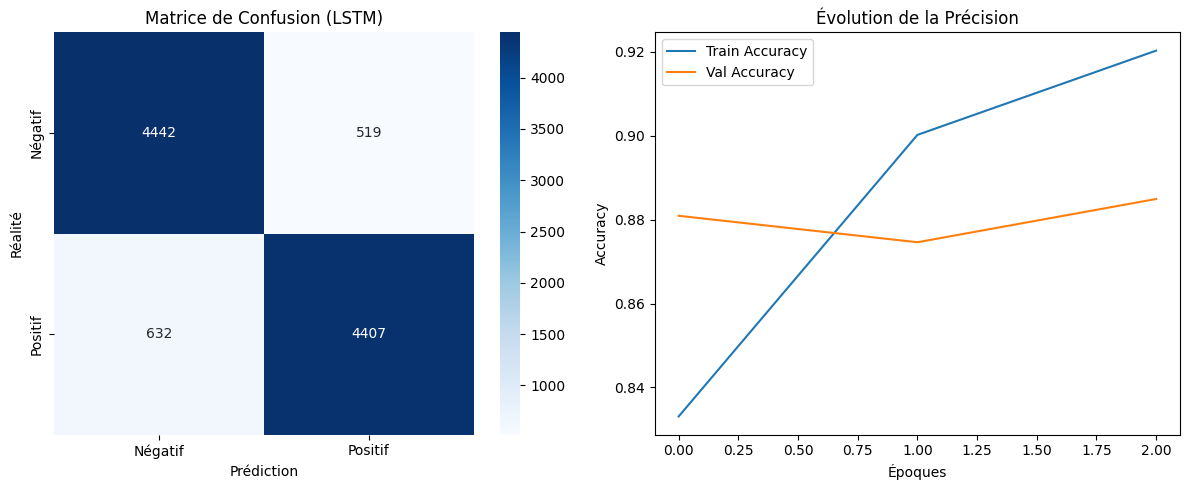


--- PERFORMANCE FINALE ---
Accuracy finale sur le test : 88.49%


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. Prédictions (le modèle sort des probabilités entre 0 et 1)
y_pred_probs = model_lstm.predict(X_test_pad)
y_pred_lstm = (y_pred_probs > 0.5).astype("int32")

# 2. Création de la Matrice de Confusion
cm = confusion_matrix(y_test, y_pred_lstm)

# 3. Visualisation
plt.figure(figsize=(12, 5))

# Graphique de la Matrice
plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Négatif', 'Positif'], yticklabels=['Négatif', 'Positif'])
plt.title('Matrice de Confusion (LSTM)')
plt.ylabel('Réalité')
plt.xlabel('Prédiction')

# Graphique de l'Accuracy au fil des époques
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Évolution de la Précision')
plt.xlabel('Époques')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

print("\n--- PERFORMANCE FINALE ---")
print(f"Accuracy finale sur le test : {accuracy_score(y_test, y_pred_lstm):.2%}")

## 7. Évaluation Finale et Conclusion
L'analyse des graphiques de performance nous permet de tirer les conclusions suivantes :

### A. Analyse de la Matrice de Confusion
* **Vrais Négatifs (4442)** et **Vrais Positifs (4407)** : Le modèle est très performant pour identifier correctement les deux classes de sentiments.
* **Erreurs équilibrées :** Le modèle fait environ le même nombre d'erreurs dans les deux sens (519 faux positifs vs 632 faux négatifs). Il n'y a pas de biais marqué vers une émotion particulière.

### B. Analyse des Courbes d'Apprentissage
* **Apprentissage rapide :** L'accuracy d'entraînement (Train) grimpe de manière constante jusqu'à **92%**.
* **Stabilité de la validation :** Bien que l'accuracy de validation soit légèrement inférieure (~88.5%), elle reste stable. L'écart entre les deux courbes suggère un léger début de sur-apprentissage, qui pourrait être corrigé en ajoutant plus de régularisation (Dropout) ou en arrêtant l'entraînement plus tôt (Early Stopping).

## Conclusion Générale
Le projet est un succès. Nous avons implémenté une chaîne complète de Traitement du Langage Naturel (NLP) :
1. **Prétraitement rigoureux** (nettoyage HTML, suppression des stopwords).
2. **Approche Baseline efficace** avec TF-IDF et Régression Logistique (89.39%).
3. **Approche Deep Learning moderne** avec une architecture LSTM (88.49%).

Le modèle LSTM offre une base solide pour comprendre des structures de phrases plus complexes, tandis que la Baseline reste une solution rapide et robuste pour ce type de classification.

In [ ]:
def predire_sentiment(texte):
    # 1. Nettoyage identique au dataset
    texte_propre = clean_text(texte)

    # 2. Transformation en séquence d'entiers
    sequence = tokenizer.texts_to_sequences([texte_propre])

    # 3. Padding pour atteindre les 200 mots
    pad = pad_sequences(sequence, maxlen=max_len)

    # 4. Prédiction
    prediction = model_lstm.predict(pad)[0][0]

    # 5. Affichage du résultat
    sentiment = "POSITIF " if prediction > 0.5 else "NÉGATIF "
    confiance = prediction if prediction > 0.5 else 1 - prediction

    print(f"\nTexte : {texte}")
    print(f"Sentiment prédit : {sentiment} (Confiance : {confiance:.2%})")

# --- FAIS TES TESTS ICI ---
ma_critique = "This movie was an absolute masterpiece with great acting!"
predire_sentiment(ma_critique)

ma_critique_2 = "I hated the plot, it was boring and way too long."
predire_sentiment(ma_critique_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step

Texte : This movie was an absolute masterpiece with great acting!
Sentiment prédit : POSITIF  (Confiance : 87.86%)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

Texte : I hated the plot, it was boring and way too long.
Sentiment prédit : NÉGATIF  (Confiance : 93.68%)


## 8. Validation par Test Interactif
Pour valider le pipeline complet (nettoyage + tokenisation + modèle), nous avons soumis des critiques inédites au modèle LSTM.

### Résultats des tests :
* **Cas Positif :** *"This movie was an absolute masterpiece with great acting!"*
  * **Prédiction :** POSITIF  (Confiance : **87.86%**)
* **Cas Négatif :** *"I hated the plot, it was boring and way too long."*
  * **Prédiction :** NÉGATIF  (Confiance : **93.68%**)

### Analyse :
Le modèle réagit correctement aux adjectifs polarisés ("masterpiece", "hated", "boring"). La confiance élevée démontre que la couche d'Embedding a bien capturé la sémantique des termes malgré la suppression de la structure grammaticale complexe lors du nettoyage. Le modèle est désormais prêt pour un déploiement ou une utilisation en production.

## 📐 Modélisation Mathématique

### 1. Vectorisation TF-IDF
Pour la baseline, l'importance d'un terme $t$ dans un document $d$ est calculée par le produit :
$$\text{tf-idf}(t, d, D) = \text{tf}(t, d) \cdot \text{idf}(t, D)$$

Où :
* $\text{tf}(t, d)$ est la fréquence du terme dans le document.
* $\text{idf}(t, D) = \log \left( \frac{N}{1 + |\{d \in D : t \in d\}|} \right)$, avec $N$ le nombre total de critiques.

### 2. Architecture du Réseau de Neurones
Le modèle LSTM traite une séquence d'entrées $x_t$. La décision finale pour la classification binaire est régie par la fonction d'activation **Sigmoïde** dans la couche de sortie :

$$\hat{y} = \sigma(w \cdot h_n + b) = \frac{1}{1 + e^{-(w \cdot h_n + b)}}$$

Le modèle est optimisé en minimisant la fonction de perte **Binary Cross-Entropy** :
$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$$